# EEG Analysis — OpenNeuro ds001787 (Meditation)

**Main library:** MNE-Python  
**Pipeline:** BIDS loading → Preprocessing → Flat channel detection → Artifact rejection → PSD analysis  
**Scope:** All subjects in the dataset

---

### How this notebook is organised

| Section | Content |
|---------|----------|
| 0–2 | Setup: install, imports, global parameters |
| 3–4 | Data acquisition: download and subject discovery |
| 5a–5e | **Pipeline functions** — one cell per step, with math explanation |
| 6 | Main loop: run the full pipeline on every subject |
| 7–11 | Group-level results: tables, PSD plots, band power, QC |
| 12 | Summary and next steps |

> 💡 Run cells **top to bottom** in order. Each section 5a–5e only *defines* a function — it does not execute it yet. Execution happens in section 6.

---
## 0. Install dependencies
Run this cell **once**, then restart the kernel if needed.

In [1]:
# Uncomment the line below and run once to install all required packages.
# The exclamation mark runs the command in the system shell from inside Jupyter.
# !pip install mne mne-bids openneuro-py matplotlib numpy scipy pandas

---
## 1. Import libraries

In [2]:
import mne                       # MNE-Python: core EEG/MEG signal processing
import mne_bids                  # BIDS-compatible file I/O built on top of MNE
import openneuro                 # Official Python client for openneuro.org
import numpy as np               # Numerical arrays, linear algebra, FFT
import pandas as pd              # Tabular data structures (DataFrame)
import matplotlib.pyplot as plt  # 2-D plotting
import warnings
from pathlib import Path         # Object-oriented filesystem paths (OS-independent)

# Reduce console noise from MNE (keep only WARNING and above)
mne.set_log_level('WARNING')
# Suppress DeprecationWarnings from scipy/numpy
warnings.filterwarnings('ignore')

print(f"MNE version:      {mne.__version__}")
print(f"MNE-BIDS version: {mne_bids.__version__}")

MNE version:      1.11.0
MNE-BIDS version: 0.17.0


---
## 2. Global parameters

All tunable thresholds and settings are centralised here.  
Changing a value in this cell automatically propagates to every function below — you never need to edit the functions themselves.

In [11]:
# ═══════════════════════════════════════════════════════════
#  GLOBAL PARAMETERS — edit only here, never inside functions
# ═══════════════════════════════════════════════════════════

# Path to the local copy of the dataset (will be created on download)
BIDS_ROOT = Path('./ds001787')

# BIDS 'task' label — must match the filename token 'task-<label>'
# Verify the exact string with mne_bids.print_dir_tree() in section 4.
TASK_NAME = 'meditation'

# BIDS session labels to load and concatenate per subject
# Set to [None] if the dataset has no session sub-folder.
SESSION_LABELS = ['01', '02']   # ses-01 and ses-02

# ── Non eeg channels ─────────────────────────────────────────
NON_EEG_CHANNELS = ['GSR1', 'GSR2', 'Resp', 'Erg1', 'Erg2',
                    'EXG1', 'EXG2', 'EXG3', 'EXG4',
                    'EXG5', 'EXG6', 'EXG7', 'EXG8']

# ── Band-pass filter ─────────────────────────────────────────
L_FREQ = 1.0    # High-pass cutoff (Hz): removes baseline drift (< 1 Hz)
H_FREQ = 40.0   # Low-pass  cutoff (Hz): removes muscle EMG and 50 Hz line noise
                # The 40 Hz cutoff sufficiently attenuates 50 Hz,
                # so a separate notch filter is not needed.

# ── Flat channel thresholds ──────────────────────────────────
# A channel is flagged as flat only when BOTH conditions are true.
FLAT_STD_THRESHOLD = 0.5e-6   # Standard deviation < 0.5 µV across the recording
FLAT_PTP_THRESHOLD = 1.0e-6   # Peak-to-peak range  < 1.0 µV across the recording

# ── Artifact rejection ───────────────────────────────────────
EPOCH_DURATION = 2.0   # Length of each analysis window in seconds
Z_THRESHOLD    = 3.0   # Z-score cutoff for peak-to-peak amplitude per channel
                       # Higher value → more permissive (keeps more data)
                       # Lower  value → stricter (removes more data)

# ── Power Spectral Density ───────────────────────────────────
PSD_FMIN  = 1.0    # Lowest  frequency included in PSD estimation (Hz)
PSD_FMAX  = 40.0   # Highest frequency included in PSD estimation (Hz)
N_FFT     = 2048   # FFT window length (samples). Frequency resolution = sfreq / N_FFT
                   # Example: sfreq=256 Hz → df = 256/2048 ≈ 0.125 Hz per bin
N_OVERLAP = 512    # Number of samples shared between adjacent Welch windows
                   # Overlap reduces variance without changing frequency resolution

# ── EEG canonical frequency bands ───────────────────────────
BAND_DEFINITIONS = {
    'delta': (0.5,  4),   # Deep sleep, large slow waves
    'theta': (4,    8),   # Drowsiness, early meditation, memory encoding
    'alpha': (8,   13),   # Relaxed wakefulness, eyes-closed rest — key band for meditation
    'beta':  (13,  30),   # Active thinking, focused attention
    'gamma': (30,  40),   # High-level sensory binding, cross-region synchrony
}

print("Global parameters set OK")

Global parameters set OK


---
## 3. Download full dataset from OpenNeuro

The dataset is hosted on [openneuro.org](https://openneuro.org/datasets/ds001787) and follows the
[BIDS standard](https://bids.neuroimaging.io/) (Brain Imaging Data Structure).  
BIDS organises data in a consistent directory hierarchy. This dataset contains **two sessions**
(`ses-01` and `ses-02`) per subject, each stored in its own sub-folder:

```
ds001787/
├── participants.tsv          ← one row per subject (age, group, …)
├── dataset_description.json  ← dataset metadata
└── sub-01/
    ├── ses-01/
    │   └── eeg/
    │       ├── sub-01_ses-01_task-meditation_eeg.set
    │       ├── sub-01_ses-01_task-meditation_channels.tsv
    │       └── sub-01_ses-01_task-meditation_events.tsv
    └── ses-02/
        └── eeg/
            ├── sub-01_ses-02_task-meditation_eeg.set
            ├── sub-01_ses-02_task-meditation_channels.tsv
            └── sub-01_ses-02_task-meditation_events.tsv
```

Both sessions are concatenated per subject before preprocessing, yielding a single
continuous signal that doubles the available clean data per participant.


In [4]:
# Path.mkdir() creates the directory if it does not yet exist.
# exist_ok=True prevents an error if the folder already exists.
BIDS_ROOT.mkdir(exist_ok=True)

# openneuro.download() streams files from the OpenNeuro S3 bucket.
# Without the 'include' argument, every file in the dataset is downloaded.
# Files already present locally are automatically skipped (incremental).
openneuro.download(
    dataset='ds001787',    # OpenNeuro accession number (visible in the URL)
    target_dir=BIDS_ROOT   # local destination path
)

print("Download complete!")


👋 Hello! This is openneuro-py 2026.3.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds001787 …


📁 Traversing directories for ds001787 : 0 entities [00:00, ? entities/s]

KeyboardInterrupt: 

---
## 4. Discover all subjects

In [4]:
# Print the folder tree up to 3 levels deep.
# Use this to verify TASK_NAME: look for filenames like sub-01_task-<label>_eeg.*
mne_bids.print_dir_tree(BIDS_ROOT, max_depth=4)

# ── Read participants.tsv ───────────────────────────────────────────────────
# BIDS mandates a participants.tsv at the dataset root.
# sep='\t' → tab-separated values (BIDS standard, not comma-separated).
participants_file = BIDS_ROOT / 'participants.tsv'
df_participants   = pd.read_csv(participants_file, sep='\t')

# The 'participant_id' column contains values like 'sub-01', 'sub-02', …
# mne_bids.BIDSPath expects ONLY the trailing ID (e.g. '01'), without 'sub-'.
# str.replace() removes the prefix from each entry.
all_subjects = [
    pid.replace('sub-', '') for pid in df_participants['participant_id'].tolist()
]

print(f"\nSubjects found: {len(all_subjects)}")
print(f"IDs: {all_subjects}")
print(f"Sessions per subject: {SESSION_LABELS}")
display(df_participants)

|ds001787\
|--- CHANGES
|--- README
|--- dataset_description.json
|--- participants.json
|--- participants.tsv
|--- task-meditation_channels.tsv
|--- task-meditation_events.json
|--- code\
|------ MW_Current_TextFileBIDS.zip
|------ README.txt
|------ run_mw_experiment6.m
|--- stimuli\
|------ cancel.wav
|------ depth.wav
|------ expe_over.wav
|------ mind_wandering.wav
|------ rate_meditation.wav
|------ rate_mw.wav
|------ rate_tired.wav
|------ resume.wav
|------ resumed.wav
|------ resumemed.wav
|------ self.wav
|------ starting.wav
|------ time.wav
|------ valence.wav
|--- sub-001\
|------ ses-01\
|--------- eeg\
|------------ sub-001_ses-01_task-meditation_eeg.bdf
|------------ sub-001_ses-01_task-meditation_eeg.json
|------------ sub-001_ses-01_task-meditation_events.tsv
|------------ .ipynb_checkpoints\
|------ ses-02\
|--------- eeg\
|------------ sub-001_ses-02_task-meditation_eeg.bdf
|------------ sub-001_ses-02_task-meditation_eeg.json
|------------ sub-001_ses-02_task-medi

,participant_id,gender,age,group
0,sub-001,M,32.0,expert
1,sub-002,M,35.0,expert
2,sub-003,F,41.0,expert
3,sub-004,M,29.0,expert
4,sub-005,F,34.0,expert
5,sub-006,M,32.0,expert
6,sub-007,M,32.0,expert
7,sub-008,M,32.0,expert
8,sub-009,M,43.0,expert
9,sub-010,M,33.0,expert


---
## 5. Pipeline functions

The full EEG processing pipeline is decomposed into **five independent functions**,
each defined in its own cell with a mathematical description above it.

This design follows the **single-responsibility principle**: each function does exactly one thing,
making it easy to replace, test, or extend individual steps without touching the rest.

| # | Function | Input | Output |
|---|----------|-------|--------|
| 5a | `load_subject` | subject ID string | `Raw` object (lazy) |
| 5c | `preprocess` | `Raw` | filtered + re-referenced `Raw` (in RAM) |
| 5b | `detect_flat_channels` | preprocessed `Raw` | list of bad channel names |
| 5d | `reject_artifacts` | preprocessed `Raw` | clean `RawArray` + stats dict |
| 5e | `compute_band_power` | clean `Raw` | PSD object + band power dict |

> ⚠️ Run all five cells below **before** running section 6.

---
### 5a — `load_subject`: BIDS file loading with multi-session concatenation

#### What is a BIDS dataset?

BIDS (Brain Imaging Data Structure) is a community standard that defines a fixed
directory layout and filename convention for neuroimaging data.  
When a dataset contains multiple sessions, each session lives in its own sub-folder:

```
sub-01_ses-01_task-meditation_eeg.set
 ↑      ↑       ↑           ↑
 subject session task        datatype + format
```

#### What the function does — computationally

`mne_bids.BIDSPath` constructs the expected file path from the key–value pairs
(subject, session, task, datatype, root). It also locates the BIDS sidecar files
(`.json`, `_channels.tsv`, `_events.tsv`) and merges their metadata into the MNE `info`
structure.

`read_raw_bids` **memory-maps** the signal file: it opens the file and sets up a
pointer, but does **not** copy the samples into RAM. Reading is deferred until
`.load_data()` is explicitly called. This is essential when looping over many subjects
— you only pay the memory cost one subject at a time.

#### Multi-session concatenation

When `SESSION_LABELS` contains more than one entry, the function loads each session
independently and concatenates them along the time axis using `mne.concatenate_raws`.

Given sessions $1, 2, \ldots, K$ with signal matrices
$\mathbf{X}^{(1)}, \mathbf{X}^{(2)}, \ldots, \mathbf{X}^{(K)} \in \mathbb{R}^{C \times T_k}$,
the concatenated recording is:

$$\mathbf{X}_{\text{concat}} = \bigl[\mathbf{X}^{(1)} \;|\; \mathbf{X}^{(2)} \;|\; \cdots \;|\; \mathbf{X}^{(K)}\bigr] \in \mathbb{R}^{C \times \sum_k T_k}$$

The concatenation introduces a **boundary annotation** between sessions
(stored as an `'BAD boundary'` and `'EDGE boundary'` annotation by MNE).
These annotations are respected by downstream steps: artifact rejection
will not merge data across session boundaries.

> **Note:** Both sessions must share the same channel layout ($C$ identical)
> and the same sampling frequency $f_s$. If any session file is missing,
> the function raises a warning and continues with the available sessions.

#### Data model

An MNE `Raw` object stores the EEG recording as a 2-D matrix:

$$\mathbf{X} \in \mathbb{R}^{C \times T}$$

where $C$ = number of channels and $T = f_s \cdot \text{duration}$ = number of time samples
at sampling frequency $f_s$, now spanning **both sessions** combined.


In [5]:
def load_subject(subject_id):
    """
    Load raw BIDS EEG data for a single subject, concatenating all sessions
    listed in SESSION_LABELS along the time axis.

    Parameters
    ----------
    subject_id : str
        BIDS subject label WITHOUT the 'sub-' prefix, e.g. '01', '12'.

    Returns
    -------
    raw : mne.io.Raw
        Raw object with all available sessions concatenated.
        If only one session is found, it is returned as-is (no concatenation).
        Data is still memory-mapped (not yet loaded into RAM).
    """
    session_raws = []   # list of Raw objects, one per session

    for ses in SESSION_LABELS:
        # mne_bids.BIDSPath builds:
        #   <BIDS_ROOT>/sub-<subject>/ses-<session>/eeg/
        #   sub-<subject>_ses-<session>_task-<task>_eeg.<ext>
        #
        # The 'session' argument adds the 'ses-<label>' token to the path.
        # If session=None, the token is omitted (single-session datasets).
        bids_path = mne_bids.BIDSPath(
            subject  = subject_id,
            session  = ses,          # e.g. '01' → ses-01 sub-folder
            task     = TASK_NAME,
            root     = BIDS_ROOT,
            datatype = 'eeg'
        )

        try:
            # read_raw_bids reads the file header and sidecar metadata.
            # verbose=False silences per-file INFO log messages.
            raw_ses = mne_bids.read_raw_bids(bids_path, verbose=False)
            session_raws.append(raw_ses)
        except FileNotFoundError:
            # Session file absent — warn and skip rather than abort.
            print(f"    [sub-{subject_id}] ses-{ses} not found — skipping.")

    if len(session_raws) == 0:
        raise RuntimeError(f"No session files found for subject {subject_id}.")

    if len(session_raws) == 1:
        # Single session: return directly, no concatenation needed.
        return session_raws[0]

    # ── Multi-session concatenation ──────────────────────────────────────────
    # Before concatenating, all sessions must be loaded into RAM
    # (mne.concatenate_raws requires in-memory data).
    # load_data() reads the signal array from the memory-mapped file.
    for r in session_raws:
        r.load_data()

    # mne.concatenate_raws joins the list along the time axis.
    # It automatically inserts 'BAD boundary' and 'EDGE boundary' annotations
    # at each junction, so downstream steps (e.g. epoch rejection) never
    # straddle a session boundary.
    #
    # All sessions must share the same:
    #   - channel names and count (C identical across sessions)
    #   - sampling frequency f_s
    # A mismatch raises an error before any data is modified.
    raw = mne.concatenate_raws(session_raws)

    return raw

print("load_subject defined OK")


load_subject defined OK


---
### 5b — `detect_flat_channels`: flat electrode identification

#### What is a flat channel and why does it matter?

A **flat channel** is an electrode that records a near-zero or constant signal
throughout the entire recording, typically caused by:
- **Broken wire** or loose connector
- **Dried conductive gel** (high impedance → amplifier clips to zero)
- **Amplifier saturation or hardware fault**

Flat channels are dangerous for two downstream reasons:
1. **Average reference contamination** — the formula $\tilde{x}_c = x_c - \bar{x}$ includes flat channels in the mean $\bar{x}$. A channel with near-zero amplitude artificially inflates the apparent amplitude of every other channel after re-referencing.
2. **Z-score distortion** — a flat channel has near-zero peak-to-peak across all epochs, so its mean $\mu_c \approx 0$ and standard deviation $\sigma_c \approx 0$. This collapses the z-score scale for that channel and can produce unreliable rejection masks.

#### Detection criteria

Channel $c$ is flagged as flat if **both** the following conditions hold
computed over the **full recording** (not per-epoch):

**Condition 1 — Standard deviation:**
$$\sigma_c = \sqrt{\frac{1}{T} \sum_{t=1}^{T} \left( x_c[t] - \bar{x}_c \right)^2} < \tau_\sigma$$

**Condition 2 — Peak-to-peak range:**
$$\text{ptp}_c = \max_{t}\, x_c[t] - \min_{t}\, x_c[t] < \tau_{\text{ptp}}$$

with $\tau_\sigma = 0.5\,\mu\text{V}$ and $\tau_{\text{ptp}} = 1.0\,\mu\text{V}$.

**Why require both conditions?**  
A channel with a single large transient spike would have a large ptp but a small std
(most of the signal is flat). Requiring both prevents mis-classifying such channels as flat.

#### Implementation detail: marking vs dropping

Flat channels are added to `raw.info['bads']` — a list of channel names to exclude —
rather than physically removed from the data array.  
MNE automatically skips `bads` in:
- `set_eeg_reference('average')` (denominator $C$ excludes bads)
- `pick_types(exclude='bads')` (used in the next function)
- `compute_psd()`, `plot_topomap()`, etc.

The raw data for bad channels is preserved and can be inspected or interpolated later.

In [6]:
def detect_flat_channels(raw_prep):
    """
    Identify flat / disconnected channels and mark them in raw_prep.info['bads'].

    A channel is flagged when BOTH conditions hold across the full recording:
      - standard deviation  < FLAT_STD_THRESHOLD  (default 0.5 µV)
      - peak-to-peak range  < FLAT_PTP_THRESHOLD   (default 1.0 µV)

    The channels are MARKED (added to info['bads']), not dropped from the array.
    MNE will automatically exclude them from all downstream computations.

    Parameters
    ----------
    raw_prep : mne.io.Raw
        Preprocessed Raw object (already filtered and re-referenced, in RAM).

    Returns
    -------
    flat_chs : list of str
        Names of channels flagged as flat. Empty list if none detected.
    """
    # raw_prep[:, :] slices ALL channels (first :) and ALL time points (second :).
    # It returns a tuple (data, times); the underscore _ discards times.
    # data.shape = (n_channels, n_samples), values in Volts.
    data, _ = raw_prep[:, :]

    # np.ndarray.std(axis=1) — standard deviation along axis=1 (time axis).
    # axis=1 means we reduce along columns (time), keeping one value per row (channel).
    # Result shape: (n_channels,) — one std value per channel.
    ch_std = data.std(axis=1)

    # np.ptp(array, axis=1) — peak-to-peak = max(axis=1) - min(axis=1).
    # Equivalent to: data.max(axis=1) - data.min(axis=1)
    # Result shape: (n_channels,)
    ch_ptp = np.ptp(data, axis=1)

    # Boolean mask of shape (n_channels,).
    # The & operator is element-wise logical AND: True only where BOTH arrays are True.
    # Parentheses are required because comparison operators have higher precedence than &.
    flat_mask = (ch_std < FLAT_STD_THRESHOLD) & (ch_ptp < FLAT_PTP_THRESHOLD)

    # np.where(condition) returns a tuple of arrays (one per dimension) of indices
    # where condition is True. [0] selects the first (and only) dimension.
    # The list comprehension maps each integer index to the channel name string.
    flat_chs = [raw_prep.ch_names[i] for i in np.where(flat_mask)[0]]

    if flat_chs:
        # Merge with any 'bads' already declared in the BIDS sidecar JSON.
        # set() removes duplicates, then list() converts back to a plain list.
        existing_bads = raw_prep.info['bads']
        raw_prep.info['bads'] = list(set(existing_bads + flat_chs))

    return flat_chs

print("detect_flat_channels defined OK")

detect_flat_channels defined OK


---
### 5c — `preprocess`: band-pass FIR filter + average reference

#### Step 1 — Band-pass FIR filter

We retain only frequencies in the band $[f_L,\, f_H] = [1,\, 40]$ Hz by convolving
the signal with a **Finite Impulse Response (FIR)** filter kernel $h[n]$.

**Time-domain** — convolution of signal $x[n]$ with kernel $h[n]$ of length $M+1$:

$$y[n] = (x * h)[n] = \sum_{k=0}^{M} h[k]\; x[n-k]$$

**Frequency-domain** — by the convolution theorem, this is equivalent to
element-wise multiplication of the DFT spectra:

$$Y(f) = H(f) \cdot X(f)$$

The ideal band-pass frequency response is:

$$H(f) = \begin{cases} 1 & f_L \le f \le f_H \\ 0 & \text{otherwise} \end{cases}$$

A real FIR filter approximates this with a smooth transition band.
The **linear-phase** property of FIR filters guarantees that all frequency components
are delayed by the same number of samples (group delay = constant),
preserving the morphology of time-domain features like event-related potentials (ERPs).

> **Why 1 Hz high-pass?**  
> Removes sub-Hz drift caused by electrode movement, sweat, cable sway, and DC offset.
>
> **Why 40 Hz low-pass?**  
> Removes muscular EMG artefacts (broadband, > 30 Hz) and 50 Hz power-line interference.
> The transition band of a 40 Hz FIR filter already attenuates 50 Hz sufficiently,
> so a separate notch filter is not needed.

---

#### Step 2 — Average reference

EEG signals are always **differential**: they measure potential differences between
an active electrode and a reference electrode. The choice of reference biases all channels.

The **average reference** replaces the physical reference with the instantaneous
mean across all $C$ channels:

$$\tilde{x}_c[n] = x_c[n] - \frac{1}{C} \sum_{c'=1}^{C} x_{c'}[n] \quad \forall\, c,\, n$$

In matrix notation (where $\mathbf{1}$ is the all-ones column vector):

$$\tilde{\mathbf{X}} = \left(\mathbf{I} - \frac{1}{C}\mathbf{1}\mathbf{1}^\top\right) \mathbf{X}$$

The matrix $\left(\mathbf{I} - \frac{1}{C}\mathbf{1}\mathbf{1}^\top\right)$ is a
**centering matrix** that projects the data onto the null space of $\mathbf{1}^\top$,
making the result independent of the original physical reference electrode,
under the assumption that the mean scalp potential is zero.

In [7]:
def preprocess(raw):
    """
    Apply a band-pass FIR filter (L_FREQ–H_FREQ Hz) to the raw EEG signal.
    Flat channel detection is applied BEFORE filtering, and average
    re-referencing is applied AFTER filtering, in the main loop.

    Parameters
    ----------
    raw : mne.io.Raw
        Raw EEG recording (in RAM, with info['bads'] already set).

    Returns
    -------
    rp : mne.io.Raw
        Band-pass filtered Raw object. The original is not modified.
    """
    rp = raw.copy().load_data()

    # ── Band-pass FIR filter ─────────────────────────────────────────────────
    rp.filter(
        l_freq  = L_FREQ,
        h_freq  = H_FREQ,
        method  = 'fir',
        verbose = False
    )

    return rp

print("preprocess defined OK")


preprocess defined OK


---
### 5d — `reject_artifacts`: z-score epoch rejection

#### Overview

Large transient artefacts (eye blinks, jaw clenches, electrode pops) produce
brief bursts of very high amplitude that contaminate spectral estimates.
We detect them by measuring how unusual each short window's amplitude is
compared to the subject's own typical amplitude distribution.

---

#### Step 1 — Epoching: divide the signal into fixed-length windows

The continuous signal $\mathbf{X} \in \mathbb{R}^{C \times T}$ is split into
$N$ non-overlapping windows of $L = \lfloor f_s \cdot T_{\text{epoch}} \rfloor$ samples:

$$\mathbf{X}^{(k)} = \mathbf{X}[:,\; kL : (k+1)L], \quad k = 0, 1, \ldots, N-1$$
$$N = \left\lfloor \frac{T}{L} \right\rfloor \quad (\text{trailing samples shorter than } L \text{ are discarded})$$

With a 2 s window and $f_s = 256$ Hz: $L = 512$ samples per epoch.

---

#### Step 2 — Peak-to-peak amplitude matrix $\mathbf{P}$

For each epoch $k$ and channel $c$:

$$p_{c,k} = \max_{t \in \mathbf{X}^{(k)}_c}\, x - \min_{t \in \mathbf{X}^{(k)}_c}\, x$$

This produces the **peak-to-peak matrix** $\mathbf{P} \in \mathbb{R}^{C \times N}$.

Peak-to-peak is preferred over variance because it is more sensitive to the isolated
large spikes produced by eye blinks and electrode pops, whereas variance is dominated
by the sustained oscillatory background.

---

#### Step 3 — Per-channel Z-score normalisation

For each channel $c$ independently, normalise each epoch's ptp by the channel's
own mean and standard deviation across all epochs:

$$z_{c,k} = \frac{p_{c,k} - \mu_c}{\sigma_c}, \qquad
\mu_c = \frac{1}{N} \sum_{k=1}^{N} p_{c,k}, \qquad
\sigma_c = \sqrt{\frac{1}{N} \sum_{k=1}^{N} \left(p_{c,k} - \mu_c\right)^2}$$

**Why normalise per channel?**  
Different electrodes have inherently different impedances and anatomical signal amplitudes.
A single global threshold would systematically flag more epochs from naturally
high-amplitude channels (e.g. near motion artefact sources) and miss artefacts
on naturally quiet channels. Per-channel normalisation removes this bias.

---

#### Step 4 — Rejection rule (logical OR across channels)

Epoch $k$ is rejected if **at least one** channel exceeds the threshold $\theta$:

$$\text{reject}_k = \bigvee_{c=1}^{C}\; \bigl[z_{c,k} > \theta\bigr]$$

Implemented as `np.any(z > θ, axis=0)` — a logical OR reduced along axis 0 (channels).

---

#### Step 5 — Reconstruction: concatenate surviving epochs

Let $\mathcal{K} = \{k : \text{reject}_k = \text{False}\}$ be the set of clean epochs.
They are joined back along the time axis:

$$\mathbf{X}_{\text{clean}} = \bigl[\mathbf{X}^{(k_1)},\; \mathbf{X}^{(k_2)},\; \ldots\bigr], \quad k_i \in \mathcal{K}$$

> **Note on temporal discontinuity:** concatenation introduces artificial gaps between
> non-adjacent accepted epochs. This breaks temporal continuity but is acceptable
> for **spectral analysis**: Welch's method treats its own internal windows independently,
> so it is robust to gaps as long as the total clean duration is sufficient.

In [8]:
def reject_artifacts(raw_prep):
    """
    Reject artifacted epochs using per-channel z-score thresholding on
    peak-to-peak amplitude.

    Steps internally:
      1. Select good EEG channels (skip info['bads'] from flat detection).
      2. Divide the signal into EPOCH_DURATION-second non-overlapping windows.
      3. Compute peak-to-peak amplitude per window per channel → matrix P (C×N).
      4. Z-score normalise P along the epoch axis, independently per channel.
      5. Reject epochs where ANY channel's z-score exceeds Z_THRESHOLD.
      6. Concatenate surviving epochs into a new Raw object.

    Parameters
    ----------
    raw_prep : mne.io.Raw
        Preprocessed Raw (filtered, re-referenced, flat channels in info['bads']).

    Returns
    -------
    raw_clean : mne.io.RawArray
        New Raw object containing only the clean, concatenated epochs.
        Bad channels have been removed from the array (they are gone here).
    stats : dict
        Keys: n_epochs_total, n_epochs_rejected, pct_rejected, duration_clean_s.
    """
    # ── 1. Select good EEG channels ─────────────────────────────────────────
    # mne.pick_types returns an integer array of channel indices.
    #   eeg=True        → keep only EEG-type channels (not EOG, EMG, stim, …)
    #   exclude='bads'  → skip channels listed in raw_prep.info['bads']
    good_picks = mne.pick_types(raw_prep.info, eeg=True, exclude='bads')

    # Index the Raw with the integer array to get the signal for good channels only.
    # Returns (data, times); we discard times with _.
    # data.shape = (n_good_channels, n_samples)  — values in Volts
    data, _ = raw_prep[good_picks, :]

    # mne.pick_info creates a copy of the info structure containing ONLY
    # the selected channels. Needed to build the output RawArray with
    # correct metadata (channel names, sampling frequency, …).
    info_clean = mne.pick_info(raw_prep.info, good_picks)

    # ── 2. Epoching parameters ───────────────────────────────────────────────
    sfreq         = raw_prep.info['sfreq']           # float: samples per second
    epoch_samples = int(EPOCH_DURATION * sfreq)      # L = floor(T_epoch * fs)
    n_ch, n_samp  = data.shape
    n_epochs      = n_samp // epoch_samples          # N = floor(T / L)
    # Note: n_samp % epoch_samples trailing samples are silently discarded.

    # ── 3. Peak-to-peak matrix P (n_channels × n_epochs) ────────────────────
    # Pre-allocate with zeros for efficiency (avoids repeated list appending).
    ptp = np.zeros((n_ch, n_epochs))

    for ep in range(n_epochs):
        s = ep * epoch_samples             # start sample index (inclusive)
        e = (ep + 1) * epoch_samples       # end sample index (exclusive)
        epoch_slice = data[:, s:e]         # shape: (n_channels, epoch_samples)

        # .max(axis=1) → maximum value over time for each channel → shape (n_ch,)
        # .min(axis=1) → minimum value over time for each channel → shape (n_ch,)
        # ptp[:, ep]   → stores one column of the P matrix
        ptp[:, ep] = epoch_slice.max(axis=1) - epoch_slice.min(axis=1)

    # ── 4. Z-score normalisation (per channel, along epoch axis) ─────────────
    # keepdims=True preserves the shape (n_channels, 1) so that NumPy broadcasting
    # correctly subtracts a (n_ch, 1) vector from a (n_ch, n_epochs) matrix.
    mean_ptp = ptp.mean(axis=1, keepdims=True)   # µ_c — shape: (n_ch, 1)
    std_ptp  = ptp.std(axis=1,  keepdims=True)   # σ_c — shape: (n_ch, 1)

    # Guard: if a channel has exactly the same ptp in every epoch, σ_c = 0.
    # Replace zero std with a tiny value to avoid division-by-zero.
    # This should be rare after flat-channel removal but is kept as a safeguard.
    std_ptp[std_ptp == 0] = 1e-10

    # Element-wise z-score: (n_ch, n_epochs) - (n_ch, 1) → broadcast → (n_ch, n_epochs)
    z_scores = (ptp - mean_ptp) / std_ptp

    # ── 5. Rejection rule ────────────────────────────────────────────────────
    # (z_scores > Z_THRESHOLD) → boolean matrix (n_ch, n_epochs); True = artefact
    # np.any(..., axis=0)      → logical OR along axis 0 (channels):
    #                            True if at least one channel exceeds threshold
    # Result shape: (n_epochs,) — one bool per epoch
    epochs_to_reject = np.any(z_scores > Z_THRESHOLD, axis=0)
    epochs_clean     = ~epochs_to_reject          # logical NOT: True = keep

    # ── 6. Concatenate surviving epochs ─────────────────────────────────────
    # List comprehension: collect the data slice for each epoch where epochs_clean[ep]=True.
    # Each element has shape (n_channels, epoch_samples).
    segments = [
        data[:, ep * epoch_samples : (ep + 1) * epoch_samples]
        for ep in range(n_epochs)
        if epochs_clean[ep]
    ]

    # np.concatenate(list, axis=1) joins all accepted slices along the time axis.
    # Result shape: (n_channels, n_clean_samples)
    data_clean = np.concatenate(segments, axis=1)

    # mne.io.RawArray wraps the numpy array back into an MNE Raw object,
    # restoring all MNE API methods (compute_psd, plot, filter, …).
    # Arguments:
    #   data    (np.ndarray) : (n_channels, n_samples) array in Volts
    #   info    (mne.Info)   : channel metadata (names, sfreq, types, …)
    #   verbose (bool)       : suppress the creation log message
    raw_clean = mne.io.RawArray(data_clean, info_clean, verbose=False)

    # ── Summary statistics ───────────────────────────────────────────────────
    stats = {
        'n_epochs_total':    n_epochs,
        'n_epochs_rejected': int(epochs_to_reject.sum()),   # True counts as 1
        'pct_rejected':      round(100 * epochs_to_reject.sum() / n_epochs, 1),
        'duration_clean_s':  round(data_clean.shape[1] / sfreq, 1),
    }
    return raw_clean, stats

print("reject_artifacts defined OK")

reject_artifacts defined OK


---
### 5e — `compute_band_power`: Welch PSD estimation and band power extraction

#### Welch's method for Power Spectral Density estimation

A single periodogram of the full signal has high variance: different realisations
of the same stochastic process give very different spectral shapes.
**Welch's method** reduces variance by **averaging periodograms** computed on
overlapping, windowed sub-segments.

Given signal $x[n]$ of length $T$, divide it into $M$ segments of length $L$ (`N_FFT`)
shifted by step $S = L - V$ (where $V$ = `N_OVERLAP` is the overlap in samples):

$$x_m[n] = x[m \cdot S + n], \quad n = 0, 1, \ldots, L-1$$

Each segment is multiplied by a **Hann window** $w[n]$ to reduce spectral leakage:

$$w[n] = \frac{1}{2}\left[1 - \cos\left(\frac{2\pi n}{L-1}\right)\right]$$

The periodogram for each windowed segment is:

$$P_m(f_k) = \frac{1}{L \|w\|^2} \left| \sum_{n=0}^{L-1} w[n]\; x_m[n]\; e^{-i 2\pi k n / L} \right|^2$$

where $f_k = k \cdot \Delta f$ and $\Delta f = f_s / L$ is the **frequency resolution**.

The Welch estimate averages all $M$ periodograms:

$$\hat{S}(f_k) = \frac{1}{M} \sum_{m=0}^{M-1} P_m(f_k)$$

Averaging $M$ independent periodograms reduces the standard error of the estimate
by a factor of $\sqrt{M}$, at the cost of frequency resolution
(longer segments → finer $\Delta f$, but fewer segments → fewer averages).

**Parameter choices:**
- `N_FFT = 2048` → with $f_s = 256$ Hz: $\Delta f = 256/2048 = 0.125$ Hz per bin
- `N_OVERLAP = 512` → 25% overlap — good trade-off between variance and bias

---

#### Conversion to decibels (dB)

PSD values span many orders of magnitude (typically $10^{-14}$–$10^{-10}\;\text{V}^2/\text{Hz}$).
Converting to **decibels** compresses this range into ~40 dB for easy visualisation:

$$P_{\text{dB}}(f) = 10 \log_{10} \hat{S}(f)$$

A difference of 10 dB corresponds to a factor of 10 in linear power.

---

#### Band power extraction

Mean power in frequency band $[f_1, f_2]$ (in linear scale, $\text{V}^2/\text{Hz}$),
averaged across all $C$ channels and all frequency bins $\mathcal{F}$ in the band:

$$\bar{P}_{\text{band}} = \frac{1}{C\; |\mathcal{F}|} \sum_{c=1}^{C} \sum_{f \in \mathcal{F}} \hat{S}_c(f)
\quad \text{where} \quad \mathcal{F} = \{f_k : f_1 \le f_k \le f_2\}$$

This scalar is then converted to dB.  
It summarises how much of the subject's total EEG power concentrates in each canonical band,
enabling single-number comparisons across subjects and conditions.

In [9]:
def compute_band_power(raw_clean):
    """
    Estimate the Power Spectral Density using Welch's method and extract
    the mean power (in dB) for each canonical EEG frequency band.

    Parameters
    ----------
    raw_clean : mne.io.Raw
        Clean Raw object (artifact-free, bad channels removed).

    Returns
    -------
    psd : mne.time_frequency.Spectrum
        MNE Spectrum object with the full PSD array and frequency axis.
        Use psd.get_data() to extract the (n_ch, n_freqs) array in V²/Hz.
    freqs : np.ndarray, shape (n_freqs,)
        Frequency axis in Hz, from PSD_FMIN to PSD_FMAX with step Delta_f.
    psd_data : np.ndarray, shape (n_channels, n_freqs)
        Raw PSD values in V²/Hz (linear scale, before dB conversion).
    band_powers : dict
        Keys: 'delta_dB', 'theta_dB', 'alpha_dB', 'beta_dB', 'gamma_dB'.
        Values: mean band power in dB, averaged over channels and frequency bins.
    """
    # ── Welch PSD estimation ─────────────────────────────────────────────────
    # raw_clean.compute_psd() wraps scipy.signal.welch for each channel.
    #
    # Arguments:
    #   method    (str)   : 'welch' — averaged periodograms (see math above)
    #                       alternative: 'multitaper' (uses DPSS windows, smoother)
    #   fmin      (float) : lowest  frequency to include in the output (Hz)
    #   fmax      (float) : highest frequency to include in the output (Hz)
    #   n_fft     (int)   : length of each FFT window in samples.
    #                       Frequency resolution = sfreq / n_fft.
    #                       Longer window → finer resolution, fewer averages.
    #   n_overlap (int)   : number of samples shared between adjacent windows.
    #                       Overlap increases effective number of averages.
    psd = raw_clean.compute_psd(
        method    = 'welch',
        fmin      = PSD_FMIN,
        fmax      = PSD_FMAX,
        n_fft     = N_FFT,
        n_overlap = N_OVERLAP
    )

    # psd.get_data() returns the PSD array as a plain NumPy array.
    # Shape: (n_channels, n_freqs)  — values in V²/Hz (linear scale)
    psd_data = psd.get_data()

    # psd.freqs is a 1-D array of frequency bin centres in Hz.
    # Shape: (n_freqs,)
    freqs = psd.freqs

    # ── Band power extraction ────────────────────────────────────────────────
    band_powers = {}

    for band_name, (fmin, fmax) in BAND_DEFINITIONS.items():
        # Boolean mask of frequency bins that fall inside the band.
        # Shape: (n_freqs,)  — True for bins in [fmin, fmax]
        freq_mask = (freqs >= fmin) & (freqs <= fmax)

        # psd_data[:, freq_mask] selects all channels and only the in-band columns.
        # Shape: (n_channels, n_in_band_freqs)
        # .mean() with no axis argument reduces to a single scalar:
        # mean over channels AND over frequency bins simultaneously.
        mean_power_linear = psd_data[:, freq_mask].mean()

        # Convert from linear V²/Hz to decibels: 10 * log10(power)
        mean_power_db = 10 * np.log10(mean_power_linear)

        # Store with key e.g. 'alpha_dB'
        band_powers[f'{band_name}_dB'] = round(mean_power_db, 3)

    return psd, freqs, psd_data, band_powers

print("compute_band_power defined OK")

compute_band_power defined OK


---
## 6. Run the full pipeline on all subjects

The five functions defined above are called in sequence for every subject.
A `try / except` block around the per-subject processing ensures that a single
subject failure (corrupt file, missing data) does not abort the entire loop.

Results are accumulated in:
- `results_rows` → converted to `results_df` (DataFrame, one row per subject)
- `psd_store` → dictionary of PSD objects keyed by subject ID (for plots in sections 8–9)
- `failed_subs` → list of subject IDs that raised an exception

In [12]:
results_rows = []
psd_store    = {}
failed_subs  = []

print(f"Processing {len(all_subjects)} subject(s) ...\n")
print(f"{'Sub':>6}  {'Flat':>5}  {'Rej%':>6}  {'Clean(s)':>9}  {'Alpha(dB)':>10}")
print('-' * 46)

#for sub in all_subjects:
for sub in all_subjects[:3]:
    try:
        # ── Step 1: Load and concatenate BIDS sessions ────────────────────────
        # Sessions listed in SESSION_LABELS are loaded and joined along the
        # time axis. Missing sessions are skipped with a warning.
        raw = load_subject(sub)
        raw.load_data()

        # ── Step 2: Drop non-EEG physiological channels ───────────────────────
        # GSR, respiration and ExG channels record non-neural signals.
        # They must be removed before average referencing — if left in, their
        # unrelated signal contaminates the reference mean and introduces
        # spurious gamma-band power in every EEG channel.
        to_drop = [ch for ch in NON_EEG_CHANNELS if ch in raw.ch_names]
        if to_drop:
            raw.drop_channels(to_drop)
            print(f"    [sub-{sub}] dropped non-EEG channels: {to_drop}")

        # ── Step 3: Flat channel detection ───────────────────────────────────
        # Flat channels (std < 0.5 µV AND ptp < 1.0 µV) are marked as bad
        # in raw.info['bads'] before any filtering.
        # Detecting them on the raw signal — before the band-pass filter — is
        # important because FIR filtering can mask a flat channel by introducing
        # filter ringing, making it appear non-flat.
        flat_chs = detect_flat_channels(raw)

        # ── Step 4: Band-pass filter 1–40 Hz ─────────────────────────────────
        # A linear-phase FIR filter retains only the 1–40 Hz band:
        #   - high-pass at 1 Hz removes DC drift, electrode movement and sweat
        #   - low-pass  at 40 Hz removes EMG and attenuates 50 Hz line noise
        # Channels in info['bads'] (set in Step 3) are automatically excluded.
        raw_filt = preprocess(raw)

        # ── Step 5: Z-score artifact rejection ───────────────────────────────
        # The signal is divided into 2 s epochs. For each channel, the
        # peak-to-peak amplitude is z-scored across epochs; any epoch where
        # at least one channel exceeds z = 3 is discarded.
        # Rejection is performed BEFORE re-referencing: removing artefactual
        # epochs first prevents high-amplitude transients from inflating the
        # reference mean in Step 6.
        raw_clean, rej_stats = reject_artifacts(raw_filt)

        # ── Step 6: Average re-reference ─────────────────────────────────────
        # Subtracts the instantaneous mean of all good EEG channels from every
        # channel, making the result independent of the physical reference
        # electrode. Applied last — after non-EEG channels are dropped (Step 2),
        # flat channels are marked bad (Step 3), and artefact epochs are removed
        # (Step 5) — so the reference mean is computed on clean EEG data only.
        raw_clean.set_eeg_reference('average', projection=False, verbose=False)

        # ── Step 7: Welch PSD + band power ───────────────────────────────────
        # Power Spectral Density is estimated on the fully preprocessed signal
        # using Welch's method (averaged periodograms with Hann windows).
        # Mean power is then extracted for each canonical EEG frequency band.
        psd_obj, freqs, psd_data, band_powers = compute_band_power(raw_clean)

        # ── Intermediate PSDs for step-by-step comparison plots ──────────────
        # A PSD snapshot is saved after each major processing step so that
        # section 8 can visualise how each operation modifies the spectrum.
        psd_raw_obj = raw.copy().compute_psd(           # after Step 2 (EEG only, unfiltered)
            method='welch', fmin=PSD_FMIN, fmax=PSD_FMAX,
            n_fft=N_FFT, n_overlap=N_OVERLAP
        )
        psd_filt_obj = raw_filt.copy().pick_types(eeg=True, exclude='bads').compute_psd(
            method='welch', fmin=PSD_FMIN, fmax=PSD_FMAX,   # after Step 4 (filtered)
            n_fft=N_FFT, n_overlap=N_OVERLAP
        )
        psd_clean_noreref = raw_clean.copy().compute_psd(   # after Step 5 (rejection, before reref)
            method='welch', fmin=PSD_FMIN, fmax=PSD_FMAX,
            n_fft=N_FFT, n_overlap=N_OVERLAP
        )

        psd_store[sub] = {
            'freqs':             freqs,
            'psd_data':          psd_data,
            'raw_psd_obj':       psd_raw_obj,        # Step 2: EEG only, unfiltered
            'filt_psd_obj':      psd_filt_obj,       # Step 4: after band-pass filter
            'clean_noreref_obj': psd_clean_noreref,  # Step 5: after z-score rejection
            'clean_psd_obj':     psd_obj,            # Step 6: after average reference (final)
        }

        row = {
            'subject':        sub,
            'n_channels':     len(raw.ch_names),
            'n_flat':         len(flat_chs),
            'flat_channels':  ', '.join(flat_chs) if flat_chs else 'none',
            'duration_raw_s': round(raw.times[-1], 1),
            **rej_stats,
            **band_powers,
        }
        results_rows.append(row)

        print(f"  {sub:>4}  {len(flat_chs):>5}  {rej_stats['pct_rejected']:>5.1f}%  "
              f"{rej_stats['duration_clean_s']:>9.1f}  {band_powers['alpha_dB']:>10.2f}")

    except Exception as exc:
        print(f"  {sub:>4}  FAILED: {exc}")
        failed_subs.append(sub)

results_df = pd.DataFrame(results_rows)
n_subs_ok  = len(results_rows)

print(f"\n{'─'*46}")
print(f"Done.  Successful: {n_subs_ok}   Failed: {len(failed_subs)}")
if failed_subs:
    print(f"Failed subjects: {failed_subs}")


Processing 24 subject(s) ...

   Sub   Flat    Rej%   Clean(s)   Alpha(dB)
----------------------------------------------
    [sub-001] dropped non-EEG channels: ['GSR1', 'GSR2', 'Resp', 'Erg1', 'Erg2', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8']
   001      1   13.1%     4726.0     -117.10
    [sub-002] dropped non-EEG channels: ['GSR1', 'GSR2', 'Resp', 'Erg1', 'Erg2', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8']
   002      1   13.9%     3924.0     -115.83
    [sub-003] dropped non-EEG channels: ['GSR1', 'GSR2', 'Resp', 'Erg1', 'Erg2', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8']
   003      1   10.3%     3306.0     -108.45

──────────────────────────────────────────────
Done.  Successful: 3   Failed: 0


---
## 7. Results table

In [13]:
# Display the full per-subject results table
display(results_df)

# Export to CSV for downstream analysis (e.g. in R, SPSS, or a statistics notebook).
# index=False prevents pandas from writing the row numbers as a column.
results_df.to_csv('results_all_subjects.csv', index=False)
print("Saved to 'results_all_subjects.csv'")

,subject,n_channels,n_flat,flat_channels,duration_raw_s,n_epochs_total,n_epochs_rejected,pct_rejected,duration_clean_s,delta_dB,theta_dB,alpha_dB,beta_dB,gamma_dB
0,001,67,1,Temp,5438.0,2719,356,13.1,4726.0,-114.703,-120.086,-117.101,-126.489,-131.019
1,002,67,1,Temp,4561.0,2280,318,13.9,3924.0,-114.657,-120.325,-115.833,-126.268,-127.646
2,003,67,1,Temp,3687.0,1843,190,10.3,3306.0,-101.001,-109.832,-108.453,-117.960,-125.037


Saved to 'results_all_subjects.csv'


In [14]:
# Descriptive statistics for band power across subjects.
# .describe() computes count, mean, std, min, quartiles, max for numeric columns.
band_cols = [c for c in results_df.columns if c.endswith('_dB')]
print("--- Band power descriptive statistics (across subjects) ---")
display(results_df[band_cols].describe().round(2))

--- Band power descriptive statistics (across subjects) ---


,delta_dB,theta_dB,alpha_dB,beta_dB,gamma_dB
count,3.00,3.00,3.00,3.00,3.00
mean,-110.12,-116.75,-113.80,-123.57,-127.90
std,7.90,5.99,4.67,4.86,3.00
min,-114.70,-120.32,-117.10,-126.49,-131.02
25%,-114.68,-120.21,-116.47,-126.38,-129.33
50%,-114.66,-120.09,-115.83,-126.27,-127.65
75%,-107.83,-114.96,-112.14,-122.11,-126.34
max,-101.00,-109.83,-108.45,-117.96,-125.04


---
## 8. PSD before vs after processing — grand average

This section computes a **grand-average PSD**: the mean PSD across all subjects,
separately for the raw signal and the clean signal.

Because different subjects may have slightly different frequency axes (due to different
recording lengths or sampling rates), we **interpolate** each subject's PSD onto a
common grid of 500 frequency points from 0.5 to 80 Hz using `np.interp`
(piecewise linear interpolation).

The grand-average PSD is then:

$$\bar{P}_{\text{grand}}(f) = \frac{1}{N_{\text{sub}}} \sum_{s=1}^{N_{\text{sub}}} \bar{P}_s(f)$$

where $\bar{P}_s(f) = \frac{1}{C_s} \sum_{c=1}^{C_s} P_{s,c}(f)$ is the mean
across channels for subject $s$.

The shaded band shows $\pm 1$ standard deviation across subjects,
indicating between-subject variability in spectral power.

In [15]:
# Guarda quali canali contribuiscono maggiormente al gamma
raw = load_subject('001')
raw.load_data()
raw_filt = preprocess(raw)

# PSD per canale
psd = raw_filt.compute_psd(method='welch', fmin=1, fmax=40, n_fft=N_FFT, n_overlap=N_OVERLAP)
psd_data = psd.get_data()  # (79, n_freqs)
freqs = psd.freqs

# Media potenza gamma (30-40 Hz) per canale
gamma_mask = (freqs >= 30) & (freqs <= 40)
gamma_power = psd_data[:, gamma_mask].mean(axis=1)

# Top 10 canali con più gamma
top_gamma_idx = gamma_power.argsort()[::-1][:10]
for i in top_gamma_idx:
    print(f"{raw_filt.ch_names[i]:10s}  gamma: {10*np.log10(gamma_power[i]):.1f} dB")

GSR1        gamma: -28.1 dB
Resp        gamma: -101.3 dB
EXG5        gamma: -102.7 dB
A28         gamma: -122.7 dB
B32         gamma: -124.0 dB
A1          gamma: -124.6 dB
B4          gamma: -125.9 dB
A2          gamma: -126.1 dB
A5          gamma: -126.5 dB
B8          gamma: -126.5 dB


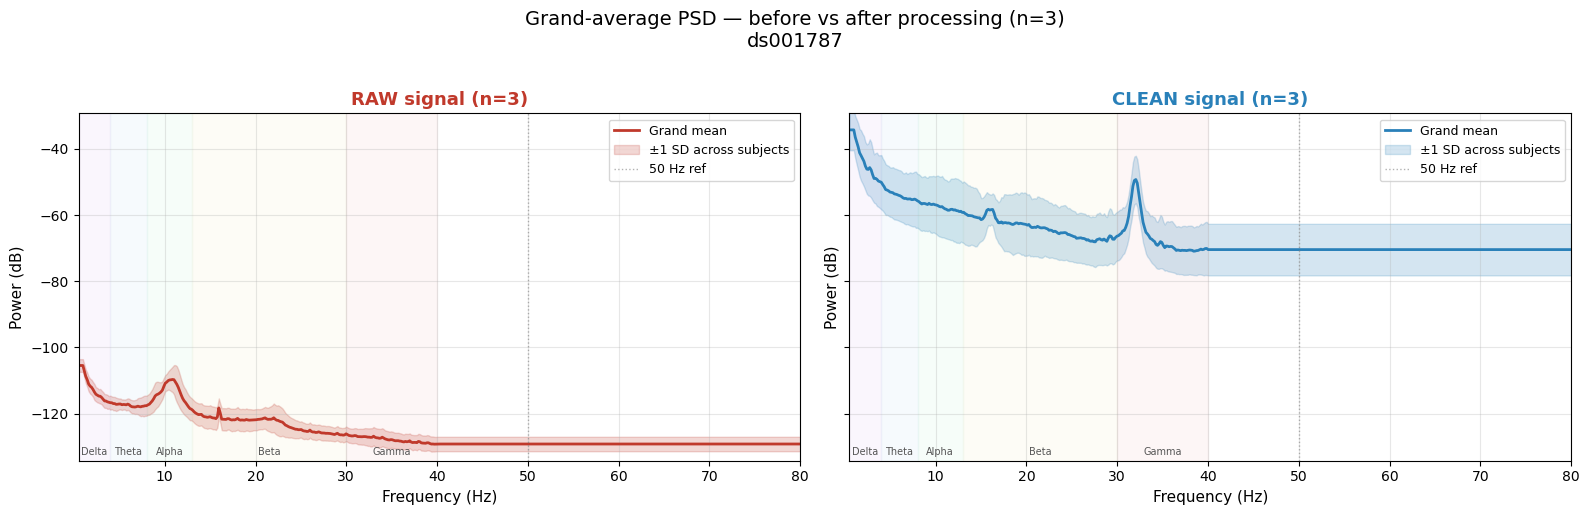

Saved: 'psd_before_after_grandavg.png'


In [20]:
# ── Common frequency axis for interpolation ──────────────────────────────────
FMIN_PLOT, FMAX_PLOT = 0.5, 80.0
# np.linspace(start, stop, num) creates an evenly spaced grid of num points
common_freqs = np.linspace(FMIN_PLOT, FMAX_PLOT, 500)   # shape: (500,)

raw_means_all   = []   # will hold one array per subject (raw PSD, mean over channels)
clean_means_all = []   # will hold one array per subject (clean PSD, mean over channels)

for sub, store in psd_store.items():
    # ── Raw PSD ──────────────────────────────────────────────────────────────
    rp = store['raw_psd_obj']
    # rp.get_data() shape: (n_ch, n_freqs_raw)
    # 10*log10(...) converts to dB, .mean(axis=0) averages over channels → shape (n_freqs_raw,)
    raw_db = 10 * np.log10(rp.get_data()).mean(axis=0)
    # np.interp(new_x, old_x, old_y) performs linear interpolation:
    # maps raw_db (defined on rp.freqs) onto common_freqs
    raw_means_all.append(np.interp(common_freqs, rp.freqs, raw_db))

    # ── Clean PSD ─────────────────────────────────────────────────────────────
    cp = store['clean_psd_obj']
    clean_db = 10 * np.log10(cp.get_data()).mean(axis=0)
    clean_means_all.append(np.interp(common_freqs, cp.freqs, clean_db))

# Stack into 2-D arrays: shape (n_subjects, 500)
# np.array(list_of_1d_arrays) creates a 2-D array where each row = one subject
raw_stack   = np.array(raw_means_all)
clean_stack = np.array(clean_means_all)

# Grand mean and SD across subjects (axis=0 = subject axis)
grand_raw_mean,   grand_raw_std   = raw_stack.mean(0),   raw_stack.std(0)
grand_clean_mean, grand_clean_std = clean_stack.mean(0), clean_stack.std(0)

# ── Shared y-axis limits ──────────────────────────────────────────────────────
y_min = min(grand_raw_mean.min(), grand_clean_mean.min()) - 5
y_max = max(grand_raw_mean.max(), grand_clean_mean.max()) + 5

# Frequency band shading: (low_hz, high_hz, colour, label)
band_spans = [
    (0.5,  4,  '#e8d5f5', 'Delta'),
    (4,    8,  '#d5e8f5', 'Theta'),
    (8,   13,  '#d5f5e3', 'Alpha'),
    (13,  30,  '#f5f0d5', 'Beta'),
    (30,  40,  '#f5d5d5', 'Gamma'),
]

# ── Plot: 1 row × 2 columns, shared y-axis ───────────────────────────────────
# sharey=True links the y-axes: zooming one also zooms the other
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, mean, std, title, color in [
    (axes[0], grand_raw_mean,   grand_raw_std,   f'RAW signal (n={n_subs_ok})',   '#c0392b'),
    (axes[1], grand_clean_mean, grand_clean_std, f'CLEAN signal (n={n_subs_ok})', '#2980b9'),
]:
    # Background shading for each canonical frequency band
    for f_lo, f_hi, c, label in band_spans:
        ax.axvspan(f_lo, f_hi, alpha=0.2, color=c)
        ax.text((f_lo + f_hi) / 2, y_min + 1, label,
                ha='center', va='bottom', fontsize=7, color='#555')

    # Grand-mean line
    ax.plot(common_freqs, mean, color=color, lw=2, label='Grand mean')

    # ±1 SD band: fill_between draws a shaded area between (mean-std) and (mean+std)
    ax.fill_between(common_freqs, mean - std, mean + std,
                    alpha=0.2, color=color, label='±1 SD across subjects')

    # Vertical reference line at 50 Hz (power-line frequency)
    ax.axvline(50, color='grey', lw=1, linestyle=':', alpha=0.6, label='50 Hz ref')

    ax.set_xlim(FMIN_PLOT, FMAX_PLOT)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_ylabel('Power (dB)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', color=color)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Grand-average PSD — before vs after processing (n={n_subs_ok})\nds001787',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('psd_before_after_grandavg.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 'psd_before_after_grandavg.png'")

---
## 9. Individual PSD curves — all subjects overlaid

Each subject's clean PSD is drawn as a thin coloured line.
The grand mean (computed in section 8) is overlaid as a thick dashed black line.

**How to read this plot:**
- Lines that lie far from the grand mean may indicate subjects with unusually
  high or low power in a particular band — potential outliers worth investigating.
- The width of the bundle of lines shows between-subject variability.

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

# Generate one colour per subject from the 'tab20' colormap.
# plt.cm.tab20 provides 20 perceptually distinct colours.
# We normalise the index to [0, 1] by dividing by (n-1).
cmap       = plt.cm.tab20
sub_colors = [cmap(i / max(len(psd_store) - 1, 1)) for i in range(len(psd_store))]

for (sub, store), color in zip(psd_store.items(), sub_colors):
    cp = store['clean_psd_obj']
    # cp.get_data().shape = (n_ch, n_freqs); mean(axis=0) → (n_freqs,)
    mean_db = 10 * np.log10(cp.get_data()).mean(axis=0)
    ax.plot(cp.freqs, mean_db, lw=1.2, alpha=0.75, color=color, label=f'sub-{sub}')

# Grand mean on top — higher zorder ensures it is drawn above individual lines
ax.plot(common_freqs, grand_clean_mean, color='black', lw=2.5,
        linestyle='--', label='Grand mean', zorder=10)

# Band background shading (same colour scheme as section 8)
for f_lo, f_hi, c, label in band_spans:
    ax.axvspan(f_lo, f_hi, alpha=0.12, color=c)

ax.set_xlim(PSD_FMIN, PSD_FMAX)
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Power (dB)', fontsize=11)
ax.set_title(f'Clean PSD — individual subjects + grand mean (n={n_subs_ok})', fontsize=12)
# ncol=4 splits the legend into 4 columns to avoid overflow with many subjects
ax.legend(fontsize=7, ncol=4, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('psd_all_subjects.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 'psd_all_subjects.png'")

---
## 10. Band power across subjects

Two complementary visualisations:

1. **Grouped bar chart** — shows the absolute band power for each subject.
   Useful for comparing individual subjects and checking consistency.

2. **Box plot** — shows the distribution of each band's power across all subjects:
   - Central line = **median**
   - Box = interquartile range (IQR = Q3 − Q1, middle 50% of the data)
   - Whiskers = Q1 − 1.5·IQR and Q3 + 1.5·IQR
   - Dots beyond whiskers = statistical outliers

In [ ]:
# ── Grouped bar chart ─────────────────────────────────────────────────────────
# Select columns whose names end with '_dB' (one per frequency band)
band_cols   = [c for c in results_df.columns if c.endswith('_dB')]
band_names  = [c.replace('_dB', '') for c in band_cols]   # strip suffix for labels
n_subs      = len(results_df)
n_bands     = len(band_cols)

# np.arange(n) creates integer positions [0, 1, …, n-1] for the x-tick locations
x = np.arange(n_subs)

# Each subject's cluster of n_bands bars must fit within 1 unit of x-space.
# width=0.15 leaves small gaps between bars for readability.
width       = 0.15
band_colors = ['#9b59b6', '#3498db', '#2ecc71', '#f39c12', '#e74c3c']

# Figure width scales with number of subjects to avoid label overlap
fig, ax = plt.subplots(figsize=(max(10, n_subs * 1.2), 5))

for i, (col, bname, color) in enumerate(zip(band_cols, band_names, band_colors)):
    # offset centres the i-th bar symmetrically within each subject's cluster:
    # i=0 → leftmost, i=n_bands-1 → rightmost
    offset = (i - n_bands / 2 + 0.5) * width
    ax.bar(
        x + offset,           # x positions for this band's bars
        results_df[col],      # bar heights (band power in dB)
        width,                # bar width
        label=bname.capitalize(),
        color=color,
        alpha=0.85
    )

ax.set_xticks(x)
ax.set_xticklabels([f'sub-{s}' for s in results_df['subject']], rotation=45, ha='right')
ax.set_ylabel('Mean power (dB)', fontsize=11)
ax.set_title('Band power per subject — clean signal', fontsize=12)
ax.legend(title='Band', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('band_power_all_subjects.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 'band_power_all_subjects.png'")

In [ ]:
# ── Box plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# Build a list of 1-D arrays, one per band: each array has n_subjects values
data_for_box = [results_df[col].values for col in band_cols]

# ax.boxplot() draws one box per element in data_for_box.
# patch_artist=True fills the box rectangle with colour (default is empty/white).
bp = ax.boxplot(data_for_box, patch_artist=True)

# bp['boxes'] is a list of matplotlib Patch objects — one per band.
# We set the fill colour and transparency for each.
for patch, color in zip(bp['boxes'], band_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Replace default x-tick labels (1, 2, 3, …) with band names
ax.set_xticklabels([b.capitalize() for b in band_names])
ax.set_ylabel('Mean power (dB)', fontsize=11)
ax.set_title('Distribution of band power across subjects', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('band_power_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 'band_power_boxplot.png'")

---
## 11. QC — artifact rejection rate per subject

This quality control chart shows what percentage of 2-second epochs were rejected
per subject. High rejection rates may indicate:
- Poor electrode contact or high impedance
- Excessive head/body movement during recording
- Persistent muscle artefacts not covered by the 1–40 Hz band-pass

**Colour thresholds (adjustable in the code):**
- 🟢 Green: < 20% rejected — acceptable data quality
- 🟠 Orange: 20–40% rejected — moderate; consider ICA or manual review
- 🔴 Red: > 40% rejected — high; subject may need exclusion or special treatment

In [ ]:
# ── Assign colour to each bar based on rejection percentage ──────────────────
# List comprehension with conditional expressions (ternary chain):
# red if p > 40, else orange if p > 20, else green
bar_colors = [
    '#e74c3c' if p > 40 else '#f39c12' if p > 20 else '#2ecc71'
    for p in results_df['pct_rejected']
]

# Figure width scales with number of subjects
fig, ax = plt.subplots(figsize=(max(8, n_subs * 0.8), 4))

# range(n_subs) provides integer x-positions [0, 1, …, n_subs-1]
ax.bar(range(n_subs), results_df['pct_rejected'], color=bar_colors, edgecolor='white')

# Horizontal dashed reference lines at the two severity thresholds
ax.axhline(40, color='red',    lw=1.5, linestyle='--', label='40% — high rejection warning')
ax.axhline(20, color='orange', lw=1.5, linestyle='--', label='20% — moderate rejection caution')

# Annotate each bar with its exact percentage above the bar
for i, pct in enumerate(results_df['pct_rejected']):
    ax.text(
        i, pct + 0.5,         # x and y position (slightly above the bar top)
        f'{pct:.1f}%',        # label text with one decimal place
        ha='center',          # horizontally centred on the bar
        va='bottom',          # vertically above the point
        fontsize=8
    )

ax.set_xticks(range(n_subs))
ax.set_xticklabels([f'sub-{s}' for s in results_df['subject']], rotation=45, ha='right')
ax.set_ylabel('Epochs rejected (%)', fontsize=11)
ax.set_title('Artifact rejection rate per subject', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
# Ensure reference lines are always visible by requiring at least 50% on y-axis
ax.set_ylim(0, max(results_df['pct_rejected'].max() + 10, 50))

plt.tight_layout()
plt.savefig('qc_rejection_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 'qc_rejection_rate.png'")

---
## 12. Summary and next steps

### What this notebook did

| Step | Method | Key parameter(s) |
|------|--------|------------------|
| Band-pass filter | Linear-phase FIR (zero phase) | 1–40 Hz |
| Average reference | Centering matrix projection | all good channels |
| Flat channel detection | std + ptp double threshold | 0.5 µV, 1.0 µV |
| Artifact rejection | Per-channel z-score on ptp | 2 s windows, z > 3 |
| PSD estimation | Welch (Hann window, averaged periodograms) | N_FFT=2048, overlap=512 |
| Band power | Mean over channels and frequency bins, dB | δ θ α β γ |

### Suggested next steps

- **ICA (Independent Component Analysis):**  
  Decompose the signal into statistically independent source components.
  Eye-blink (EOG) and heartbeat (ECG) components can be identified and subtracted
  without discarding entire epochs — especially valuable for short recordings.

- **Statistical testing:**  
  Paired t-test or non-parametric Wilcoxon signed-rank test to compare alpha power
  between groups (e.g. expert meditators vs novices if the dataset includes this).

- **Event-locked epoching:**  
  If event markers are present in the `_events.tsv` files, segment the signal into
  short windows around each event to study event-related spectral perturbations (ERSP).

- **Time-frequency analysis:**  
  Use Short-Time Fourier Transform (STFT) or Morlet wavelet convolution to track
  how power in each band evolves across the duration of the meditation session.

- **Coherence / Phase-Locking Value (PLV):**  
  Measure functional connectivity between electrode pairs to assess how synchronised
  different brain regions are during meditation.